## Dự đoán Aggregate Rating nhà hàng theo mô hình XGBoost

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import utils
import importlib
importlib.reload(utils)
from utils import check_overfitting
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)

from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report
from utils import check_overfitting

REVIEW DATASET SAU KHI ĐÃ XỬ LÍ

In [82]:
df = pd.read_csv('../../data/processed/clean_ds_train_data.csv')
df_model = df.copy()

# Tạo nhãn khoảng
bins = [0, 3.0, 4.0, 5.0]
labels = [0, 1, 2]
label_names = ['Thấp (< 3.0)', 'Trung bình (3.0–4.0)', 'Tốt (≥ 4.0)']

rating_class = pd.cut(df_model['Aggregate rating'], bins=bins, labels=labels, include_lowest=True).astype(int)

print('Aggregate rating phân bố theo các khoảng:')
counts = rating_class.value_counts().sort_index()
for i, cnt in counts.items():
    print(f'  Khoảng {i} ({label_names[i]}): {cnt} mẫu ({cnt/len(rating_class)*100:.1f}%)')

Aggregate rating phân bố theo các khoảng:
  Khoảng 0 (Thấp (< 3.0)): 1901 mẫu (25.7%)
  Khoảng 1 (Trung bình (3.0–4.0)): 4388 mẫu (59.3%)
  Khoảng 2 (Tốt (≥ 4.0)): 1114 mẫu (15.0%)


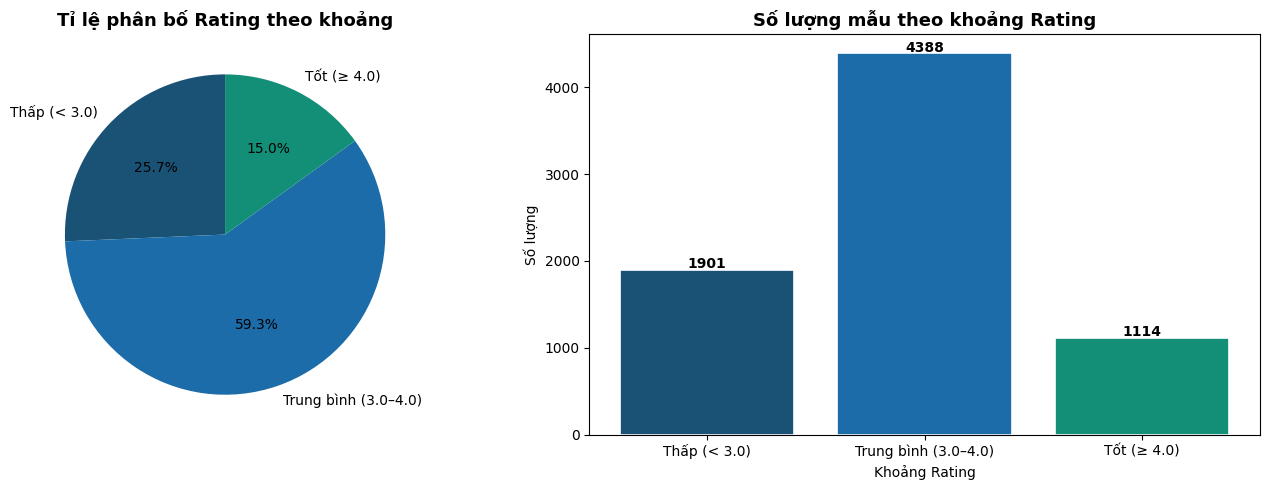

In [83]:
# Visualize 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#1a5276', '#1b6ca8', '#148f77']
counts_vals = [counts[i] for i in range(3)]  

axes[0].pie(counts_vals, labels=label_names, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[0].set_title('Tỉ lệ phân bố Rating theo khoảng', fontsize=13, fontweight='bold')

bars = axes[1].bar(label_names, counts_vals, color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, counts_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(val), ha='center', fontweight='bold')
axes[1].set_title('Số lượng mẫu theo khoảng Rating', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Khoảng Rating')
axes[1].set_ylabel('Số lượng')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

CHỌN ĐẶC TRƯNG CẦN DÙNG VÀ TÁCH DATASET

In [84]:
target = 'Aggregate rating' 
features = [col for col in df_model.columns if col != target]

X = df_model[features]
y_c = rating_class
y_r = df_model['Aggregate rating']

print(f'Số features: {len(features)}')
print(f'Số samples: {len(X)}')

Số features: 10
Số samples: 7403


In [85]:
X_train_c, X_valid_c, y_train_c, y_valid_c = train_test_split(
    X, y_c,
    test_size=0.2,
    random_state=42,
    stratify=y_c  
)

print(f'Train set: {X_train_c.shape[0]} mẫu')
print(f'Valid set: {X_valid_c.shape[0]} mẫu')

Train set: 5922 mẫu
Valid set: 1481 mẫu


In [86]:
X_train_r, X_valid_r, y_train_r, y_valid_r = train_test_split(
    X, y_r,
    test_size=0.2,
    random_state=42
)

print(f'Train set: {X_train_r.shape[0]} mẫu')
print(f'Valid set: {X_valid_r.shape[0]} mẫu')

Train set: 5922 mẫu
Valid set: 1481 mẫu


HUẤN LUYỆN MÔ HÌNH XGBOOST CLASSIFIER

In [87]:
# 1. Tính toán trọng số tự động (thay thế cho đoạn tính tay phức tạp)
sample_weights_c = compute_sample_weight(class_weight='balanced', y=y_train_c)

# 2. Khởi tạo XGBoost (giữ nguyên cấu hình tốt của bạn)
xgb_model_c = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    reg_alpha=1,
    reg_lambda=1,
    subsample=0.7,
    n_jobs=-1,
    random_state=42
)

# 3. Huấn luyện (Giờ thì code đã cực kỳ gọn và thống nhất với RF)
xgb_model_c.fit(X_train_c, y_train_c, sample_weight=sample_weights_c)
print('Huấn luyện mô hình XGBoost classifier hoàn tất!')

Huấn luyện mô hình XGBoost classifier hoàn tất!


ĐÁNH GIÁ MÔ HÌNH XGBOOST CLASSIFIER

In [88]:
y_pred_c = xgb_model_c.predict(X_valid_c)

acc = accuracy_score(y_valid_c, y_pred_c)
f1_macro = f1_score(y_valid_c, y_pred_c, average='macro')
f1_weighted = f1_score(y_valid_c, y_pred_c, average='weighted')

print(f'Accuracy       : {acc:.4f} ({acc*100:.2f}%)')
print(f'F1 (macro)     : {f1_macro:.4f}')
print(f'F1 (weighted)  : {f1_weighted:.4f}')

print()
print('Classification Report:')
print(classification_report(
    y_valid_c, 
    y_pred_c, 
    target_names=['Thấp', 'Trung bình', 'Tốt'] 
))

Accuracy       : 0.6246 (62.46%)
F1 (macro)     : 0.6304
F1 (weighted)  : 0.6241

Classification Report:
              precision    recall  f1-score   support

        Thấp       0.51      0.73      0.60       380
  Trung bình       0.78      0.52      0.62       878
         Tốt       0.55      0.85      0.67       223

    accuracy                           0.62      1481
   macro avg       0.61      0.70      0.63      1481
weighted avg       0.67      0.62      0.62      1481



In [89]:
# Đánh giá theo Cross-validation 5-fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_model_c, X, y_c, cv=cv, scoring='f1_macro', n_jobs=-1)

print(f'Cross-Validation (5-fold) F1 macro:')
print(f'Scores: {[round(s, 4) for s in cv_scores]}')
print(f'Mean  : {cv_scores.mean():.4f}')
print(f'Std   : {cv_scores.std():.4f}')

Cross-Validation (5-fold) F1 macro:
Scores: [np.float64(0.6225), np.float64(0.6601), np.float64(0.6673), np.float64(0.639), np.float64(0.6368)]
Mean  : 0.6452
Std   : 0.0163


KIỂM TRA OVERFITTING CHO CLASSIFICATION

In [90]:
check_overfitting(xgb_model_c, X_train_c, y_train_c, X_valid_c, y_valid_c, task='classification')

Kiểm tra Overfitting cho mô hình: classification
Accuracy - Train: 0.6378, Valid: 0.6246
Mô hình ổn định


CONFUSION MATRIX XGBOOST CLASSIFIER

In [91]:
cm = confusion_matrix(y_valid_c, y_pred_c)

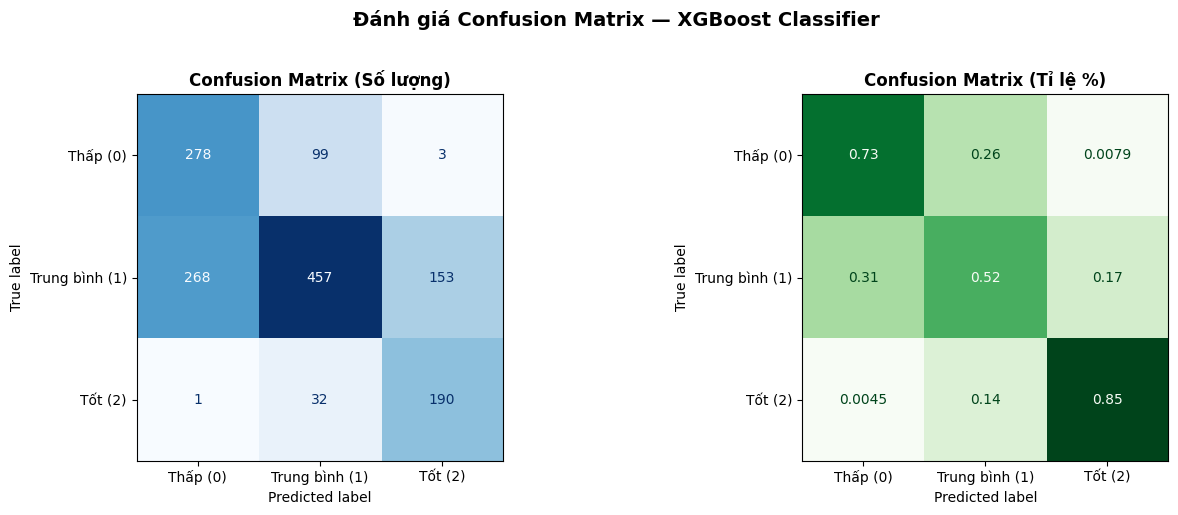

In [92]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=['Thấp (0)', 'Trung bình (1)', 'Tốt (2)'])
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Số lượng)', fontweight='bold')

cm_norm = confusion_matrix(y_valid_c, y_pred_c, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                display_labels=['Thấp (0)', 'Trung bình (1)', 'Tốt (2)'])
disp2.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix (Tỉ lệ %)', fontweight='bold')

plt.suptitle('Đánh giá Confusion Matrix — XGBoost Classifier', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

HUẤN LUYỆN MÔ HÌNH XGBOOST REGRESSOR

In [93]:
xgb_model_r = XGBRegressor(
    n_estimators=150,       # Giảm từ 200-500 xuống 150
    max_depth=4,            # Giảm độ sâu để cây không "mọc" quá dài
    learning_rate=0.05,     # Tốc độ học chậm hơn để mô hình học chắc hơn
    reg_alpha=2,            # Thêm Regularization L1 (phạt các trọng số lớn)
    reg_lambda=2,           # Thêm Regularization L2
    subsample=0.7,          # Dùng 70% dữ liệu mỗi lượt để chống "học thuộc lòng"
    colsample_bytree=0.7,   # Dùng 70% đặc trưng mỗi lượt
    n_jobs=-1,
    random_state=42
)

xgb_model_r.fit(X_train_r, y_train_r)
print('Huấn luyện XGBoost regressor hoàn tất!')

Huấn luyện XGBoost regressor hoàn tất!


ĐÁNH GIÁ MÔ HÌNH XGBOOST REGRESSOR

In [94]:
y_pred_r = xgb_model_r.predict(X_valid_r)

mae = mean_absolute_error(y_valid_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_valid_r, y_pred_r))
r2 = r2_score(y_valid_r, y_pred_r)

print(f'Mean Abs Error (MAE)  : {mae:.4f}')
print(f'Root Mean Sq E (RMSE) : {rmse:.4f}')
print(f'R-squared      (R²)   : {r2:.4f}')
print(f'\nÝ nghĩa: Trung bình dự đoán sai lệch ±{mae:.3f} điểm so với thực tế')

Mean Abs Error (MAE)  : 0.2544
Root Mean Sq E (RMSE) : 0.3402
R-squared      (R²)   : 0.6258

Ý nghĩa: Trung bình dự đoán sai lệch ±0.254 điểm so với thực tế


In [95]:
# Đánh giá theo Cross-validation
cv_r = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_r_mae = cross_val_score(xgb_model_r, X, y_r, cv=cv_r, scoring='neg_mean_absolute_error', n_jobs=-1)
cv_scores_r_r2 = cross_val_score(xgb_model_r, X, y_r, cv=cv_r, scoring='r2', n_jobs=-1)

print('Cross-Validation (5-fold) — Regressor:')
print(f'MAE Scores  : {[round(-s, 4) for s in cv_scores_r_mae]}')
print(f'MAE Mean    : {-cv_scores_r_mae.mean():.4f} ± {cv_scores_r_mae.std():.4f}')
print(f'R² Scores   : {[round(s, 4) for s in cv_scores_r_r2]}')
print(f'R² Mean     : {cv_scores_r_r2.mean():.4f} ± {cv_scores_r_r2.std():.4f}')

Cross-Validation (5-fold) — Regressor:
MAE Scores  : [np.float64(0.2541), np.float64(0.279), np.float64(0.2576), np.float64(0.2521), np.float64(0.262)]
MAE Mean    : 0.2610 ± 0.0096
R² Scores   : [np.float64(0.627), np.float64(0.5489), np.float64(0.5866), np.float64(0.6127), np.float64(0.5967)]
R² Mean     : 0.5944 ± 0.0266


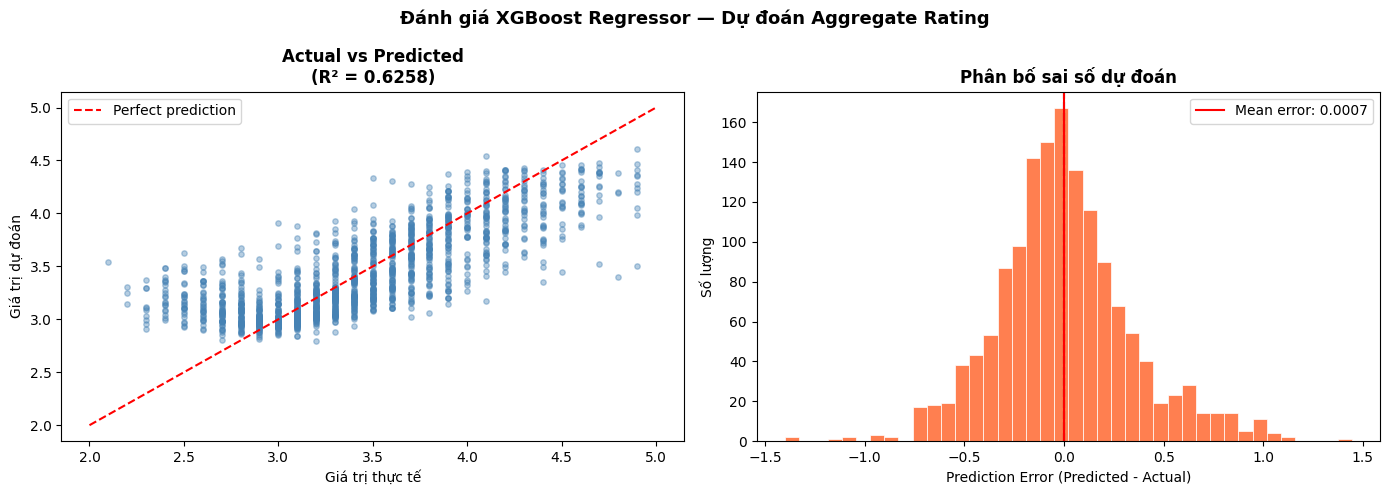

In [96]:
# Visualize: Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_valid_r, y_pred_r, alpha=0.4, color='steelblue', s=15)
lims = [min(y_valid_r.min(), y_pred_r.min()) - 0.1,
        max(y_valid_r.max(), y_pred_r.max()) + 0.1]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Giá trị thực tế')
axes[0].set_ylabel('Giá trị dự đoán')
axes[0].set_title(f'Actual vs Predicted\n(R² = {r2:.4f})', fontweight='bold')
axes[0].legend()

errors = y_pred_r - y_valid_r.values
axes[1].hist(errors, bins=40, color='coral', edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].axvline(errors.mean(), color='red', linestyle='-', linewidth=1.5, label=f'Mean error: {errors.mean():.4f}')
axes[1].set_xlabel('Prediction Error (Predicted - Actual)')
axes[1].set_ylabel('Số lượng')
axes[1].set_title('Phân bố sai số dự đoán', fontweight='bold')
axes[1].legend()

plt.suptitle('Đánh giá XGBoost Regressor — Dự đoán Aggregate Rating', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

KIỂM TRA OVERFITTING CHO REGRESSION

In [97]:
check_overfitting(xgb_model_r, X_train_r, y_train_r, X_valid_r, y_valid_r, task='regression')

Kiểm tra Overfitting cho mô hình: regression
MAE  - Train: 0.2493, Valid: 0.2544
R²   - Train: 0.6261, Valid: 0.6258
Mô hình ổn định (Gap giữa Train và Valid nhỏ).


FEATURE IMPORTANCE CỦA CLASSIFIER VÀ REGRESSOR

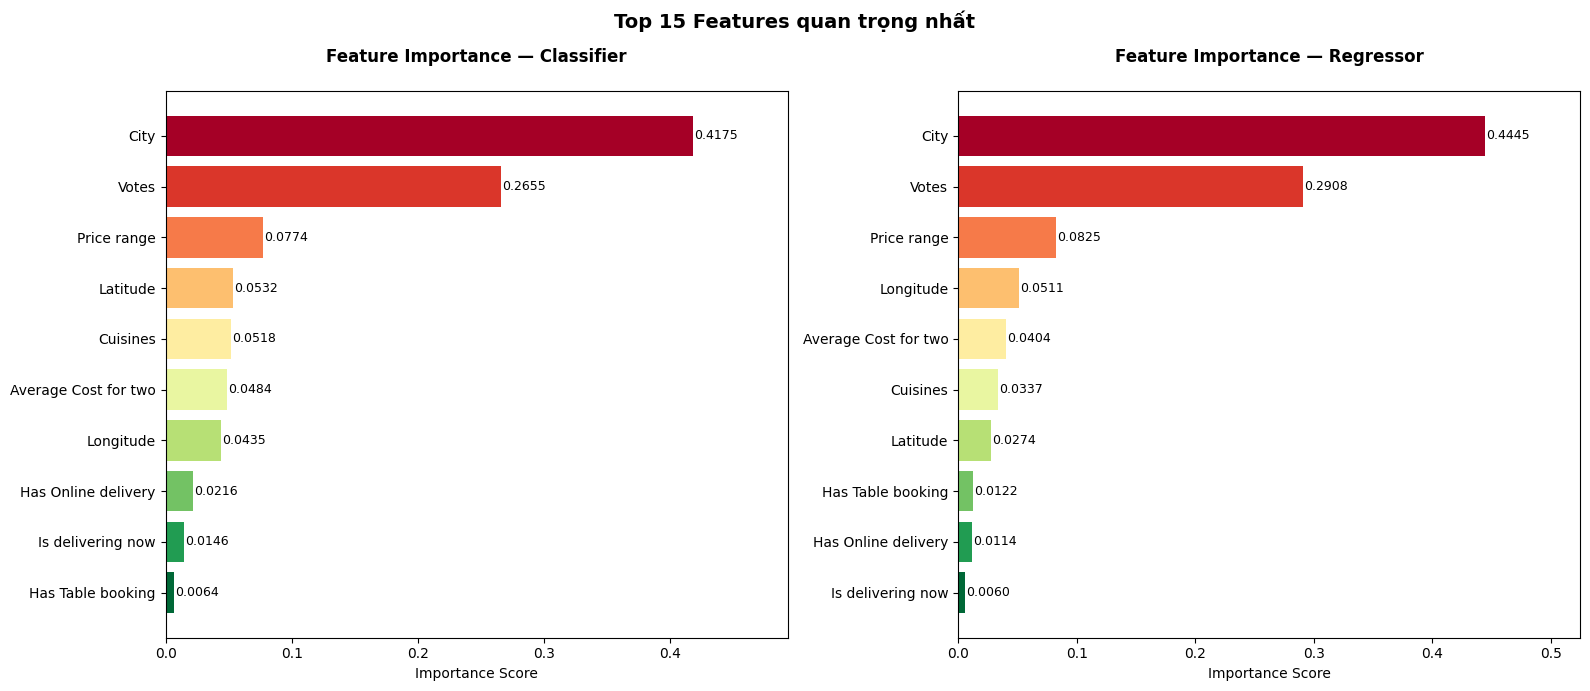

In [98]:
def plot_feature_importance(model, features, title, ax, top_n=15):
    importances = model.feature_importances_
    feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})\
                .sort_values('Importance', ascending=False).head(top_n)
    
    colors_bar = plt.cm.RdYlGn_r(np.linspace(0, 1, len(feat_df)))
    bars = ax.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1], color=colors_bar)
    
    for bar, val in zip(bars, feat_df['Importance'][::-1]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    
    ax.set_xlabel('Importance Score')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(0, feat_df['Importance'].max() * 1.18)
    return feat_df

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

feat_clf = plot_feature_importance(xgb_model_c, features, 'Feature Importance — Classifier\n', axes[0])
feat_reg = plot_feature_importance(xgb_model_r, features, 'Feature Importance — Regressor\n', axes[1])

plt.suptitle('Top 15 Features quan trọng nhất', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()